白化变换
白化结果：
[[-1.41441507 -0.2201997 ]
 [ 0.19311634 -0.40826654]
 [ 0.50956069 -2.07475942]
 [ 0.58659471  0.88633071]
 [ 0.49267988 -1.69881068]
 [ 0.37251314 -1.65150305]
 [-1.1660899  -0.57207536]
 [ 0.47317591 -1.34782784]
 [ 0.32970032 -0.93829952]
 [-1.44260795  0.45619646]]
U矩阵：
[[-1.41441507 -0.2201997 ]
 [ 0.19311634 -0.40826654]
 [ 0.50956069 -2.07475942]
 [ 0.58659471  0.88633071]
 [ 0.49267988 -1.69881068]
 [ 0.37251314 -1.65150305]
 [-1.1660899  -0.57207536]
 [ 0.47317591 -1.34782784]
 [ 0.32970032 -0.93829952]
 [-1.44260795  0.45619646]]
白化矩阵W与U是否相等：True


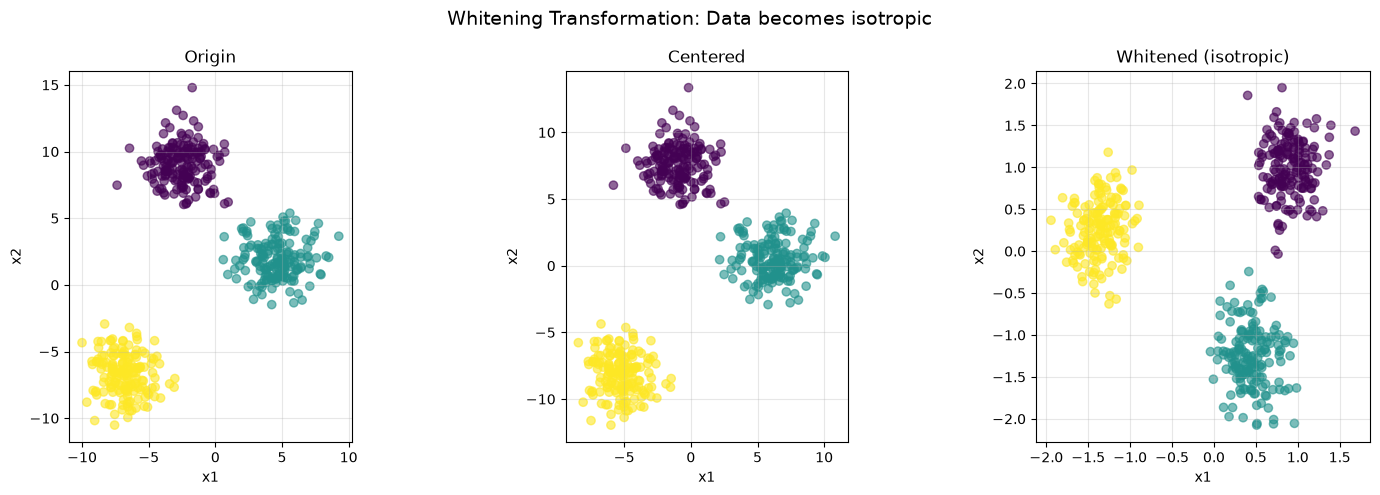


白化后的协方差矩阵:
[[1. 0.]
 [0. 1.]]
接近单位矩阵？ True


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs

# ---- 生成数据 ----
X, y = make_blobs(n_samples=500, centers=3, n_features=2, 
                  cluster_std=1.5, random_state=42)

print("=" * 60)
print("白化变换")
print("=" * 60)

# ---- 1. 中心化 ----
X_centered = X - np.mean(X, axis=0)

# ---- SVD ----
U, S, V = np.linalg.svd(X_centered, full_matrices=True)

# ---- 2. PCA ----
cov = np.cov(X_centered.T)
eigvals, eigvecs = np.linalg.eigh(cov)
# 按特征值降序
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# ---- 3. 白化 ----
# 白化矩阵: W = Σ^{-1/2} V^T
W = np.diag(1/np.sqrt(eigvals)) @ eigvecs.T
X_whitened = X_centered @ W.T

# ---- 3.5 结果是 U 吗？ ----
print(f"白化结果：\n{X_whitened[:10]}")
print(f"U 矩阵：\n{U[:10, :2] * np.sqrt(499)}")
print(f"白化矩阵 W 与 U 是否相等：{np.allclose(X_whitened, U[:, :2] * np.sqrt(499))}")

# ---- 可视化 ----
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 原始数据
axes[0].scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', alpha=0.6)
axes[0].set_title('Origin')
axes[0].set_xlabel('x1')
axes[0].set_ylabel('x2')
axes[0].grid(alpha=0.3)
axes[0].set_aspect('equal')

# 中心化后
axes[1].scatter(X_centered[:, 0], X_centered[:, 1], c=y, cmap='viridis', alpha=0.6)
axes[1].set_title('Centered')
axes[1].set_xlabel('x1')
axes[1].set_ylabel('x2')
axes[1].grid(alpha=0.3)
axes[1].set_aspect('equal')

# 白化后
axes[2].scatter(X_whitened[:, 0], X_whitened[:, 1], c=y, cmap='viridis', alpha=0.6)
# axes[2].set_title('白化后 (各向同性)')
axes[2].set_title('Whitened (isotropic)')
axes[2].set_xlabel('x1')
axes[2].set_ylabel('x2')
axes[2].grid(alpha=0.3)
axes[2].set_aspect('equal')

# plt.suptitle('白化变换：数据变成各向同性', fontsize=14)
plt.suptitle('Whitening Transformation: Data becomes isotropic', fontsize=14)
plt.tight_layout()
plt.show()

# ---- 验证协方差 ----
cov_whitened = np.cov(X_whitened.T)
print(f"\n白化后的协方差矩阵:\n{cov_whitened.round(3)}")
print(f"接近单位矩阵？ {np.allclose(cov_whitened, np.eye(2), atol=0.1)}")